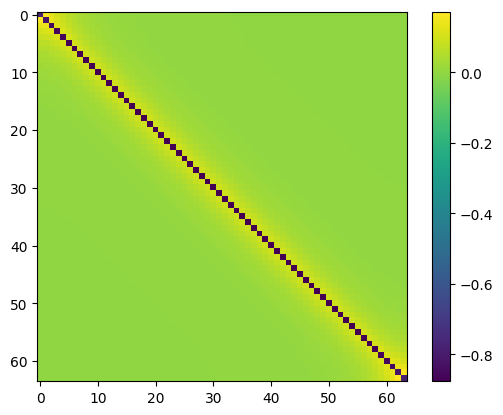

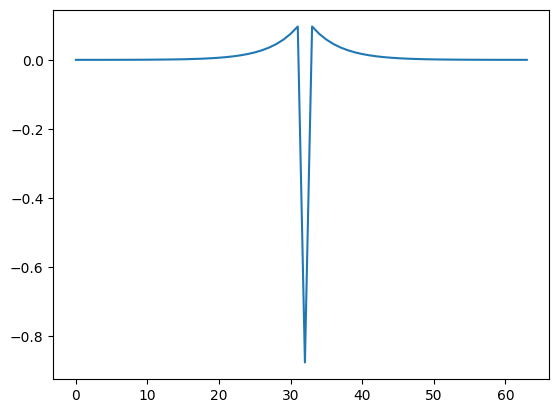

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 64
velocity_kernel = np.zeros((N - 1, N))
velocity_kernel[:, 1:] = np.eye(N - 1)
velocity_kernel -= np.eye(N - 1, N)
K = velocity_kernel.T @ velocity_kernel
sigma = 4

score_kernel = -np.linalg.inv(K + np.eye(N) / (sigma ** 2)) @ K
plt.imshow(score_kernel)
plt.colorbar()
plt.show()

plt.plot(score_kernel[N // 2])
plt.show()


## Approach 1 for computing obstacle-based energy landscape

Here, I try direct integration. However, I don't think this approach is very feasible.

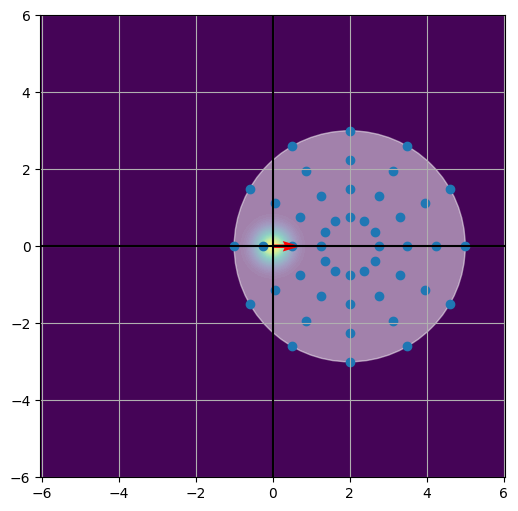

In [ ]:
import matplotlib.patches as patches

c_x = 2
R: float = 3

plt.figure(figsize=(6, 6))
plt.axis("equal")

# Color according to Gaussian.
gaussian_xx, gaussian_yy = np.meshgrid(
    np.linspace(-6, 6, 128),
    np.linspace(-6, 6, 128),
)
sigma = 0.3
gaussian_probability = (
    1
    / (2 * np.pi * sigma**2)
    * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma**2)
)
plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)
# plt.xlim(-6, 6)
plt.ylim(-6, 6)

plt.gca().axvline(x=0, color="k")
plt.gca().axhline(y=0, color="k")
plt.grid()
plt.gca().add_patch(patches.Circle((c_x, 0), R, fill=True, color="white", alpha=0.5))

N_segments = 12
angles = np.linspace(0, 2 * np.pi, N_segments, endpoint=False)
x = R * np.column_stack([np.cos(angles), np.sin(angles)])
evaluation_locations = np.concatenate([x, x * 0.75, x * 0.5, x * 0.25])
evaluation_locations[:, 0] += c_x
plt.scatter(evaluation_locations[:, 0], evaluation_locations[:, 1])

gaussian_evaluations = np.exp(
    -0.5
    * (evaluation_locations[:, 0] ** 2 + evaluation_locations[:, 1] ** 2)
    / sigma**2
)
gaussian_first_moment = (gaussian_evaluations[:, None] * evaluation_locations).sum(
    axis=0
)
denominator = gaussian_evaluations.sum()

displacement_direction = -1 / (2 * sigma**2) * gaussian_first_moment / denominator

plt.quiver(
    0, 0, displacement_direction[0], displacement_direction[1], color="red", scale=5
)

plt.show()

## Approach 2 for computing obstacle energy landscape

This approach is also numerical, but in terms of a much more precise integral.

In [111]:
import time
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np


def compute_agent_obstacle_score(
    agent_x, agent_y, obs_x, obs_y, obs_rad, sigma, n_integral=10
):
    d_a_o = np.sqrt((agent_x - obs_x) ** 2 + (agent_y - obs_y) ** 2)
    R = np.array(
        [
            [obs_x - agent_x, agent_y - obs_y],
            [obs_y - agent_y, obs_x - agent_x],
        ]
    )
    R = R / d_a_o

    # Compute numerator.
    r1 = min(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r2 = max(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r_values = np.linspace(r1, r2, n_integral, endpoint=False)
    dr = r_values[1] - r_values[0]
    r_values = r_values + dr / 2

    denominator_first_int = 1 - np.exp(-0.5 * (r1**2) / (sigma**2))
    denominator_third_int = -np.exp(-0.5 * (r2**2) / (sigma**2))

    if d_a_o < obs_rad:
        denominator_first_int = 0

    denominator = denominator_first_int + denominator_third_int
    numerator = 0.0

    for r in r_values:
        intersection_eps_x = -(obs_rad**2 - r**2 - d_a_o**2) / (2 * d_a_o)
        intersection_eps_y = np.sqrt(r**2 - intersection_eps_x**2)
        numerator_integrand = (
            r
            * np.exp(-0.5 * (r**2) / (sigma**2))
            * intersection_eps_y
            / (2 * np.pi * sigma**2)
        )
        numerator += numerator_integrand * dr

        Theta = np.arccos(intersection_eps_x / r)

        denominator += (
            2
            * r
            * (np.exp(-0.5 * (r**2) / (sigma**2)) / (2 * np.pi * sigma**2))
            * dr
            * Theta
        )

    numerator = R[:, 0] * numerator
    score = -1 / (2 * sigma**2) * numerator / denominator

    return score


def compute_agent_obstacle_score_vectorized(
    agent_x, agent_y, obs_x, obs_y, obs_rad, sigma, n_integral=10
):
    d_a_o = np.sqrt((agent_x - obs_x) ** 2 + (agent_y - obs_y) ** 2)
    R = np.array(
        [
            [obs_x - agent_x, agent_y - obs_y],
            [obs_y - agent_y, obs_x - agent_x],
        ]
    )
    R = R / d_a_o

    # Compute numerator.
    r1 = min(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r2 = max(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r_values = np.linspace(r1, r2, n_integral, endpoint=False)
    dr = r_values[1] - r_values[0]
    r_values = r_values + dr / 2

    denominator_first_int = 1 - np.exp(-0.5 * (r1**2) / (sigma**2))
    denominator_third_int = -np.exp(-0.5 * (r2**2) / (sigma**2))

    if d_a_o < obs_rad:
        denominator_first_int = 0

    denominator = denominator_first_int + denominator_third_int
    numerator = 0.0

    intersection_eps_x = -(obs_rad**2 - r_values**2 - d_a_o**2) / (2 * d_a_o)
    intersection_eps_y = np.sqrt(r_values**2 - intersection_eps_x**2)
    numerator_integrand = (
        r_values * np.exp(-0.5 * (r_values**2) / (sigma**2)) * intersection_eps_y
    )
    numerator += numerator_integrand.sum() * (dr / (2 * np.pi * sigma**2))

    Theta = np.arccos(intersection_eps_x / r_values)

    denominator += (
        r_values
        * (np.exp(-0.5 * (r_values**2) / (sigma**2)) / (2 * np.pi * sigma**2))
        * Theta
    ).sum() * (2 * dr)

    numerator = R[:, 0] * numerator
    score = -1 / (2 * sigma**2) * numerator / denominator

    return score

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


6.103515625e-05
5 1 [-3.74115729e-40 -0.00000000e+00]
4.7206878662109375e-05
2.5 1 [-7.76371214e-07 -0.00000000e+00]
6.389617919921875e-05
0.5 1 [-0.61780451 -0.        ]
5.507469177246094e-05
5 3 [-5.91191373e-11 -0.00000000e+00]
5.1975250244140625e-05
2.5 3 [-0.4640147 -0.       ]
4.7206878662109375e-05
0.5 3 [-0.90566861 -0.        ]
5.793571472167969e-05
5 5 [-0.67948874 -0.        ]
4.601478576660156e-05
2.5 5 [-0.53080148 -0.        ]
4.696846008300781e-05
0.5 5 [-1.14562583 -0.        ]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

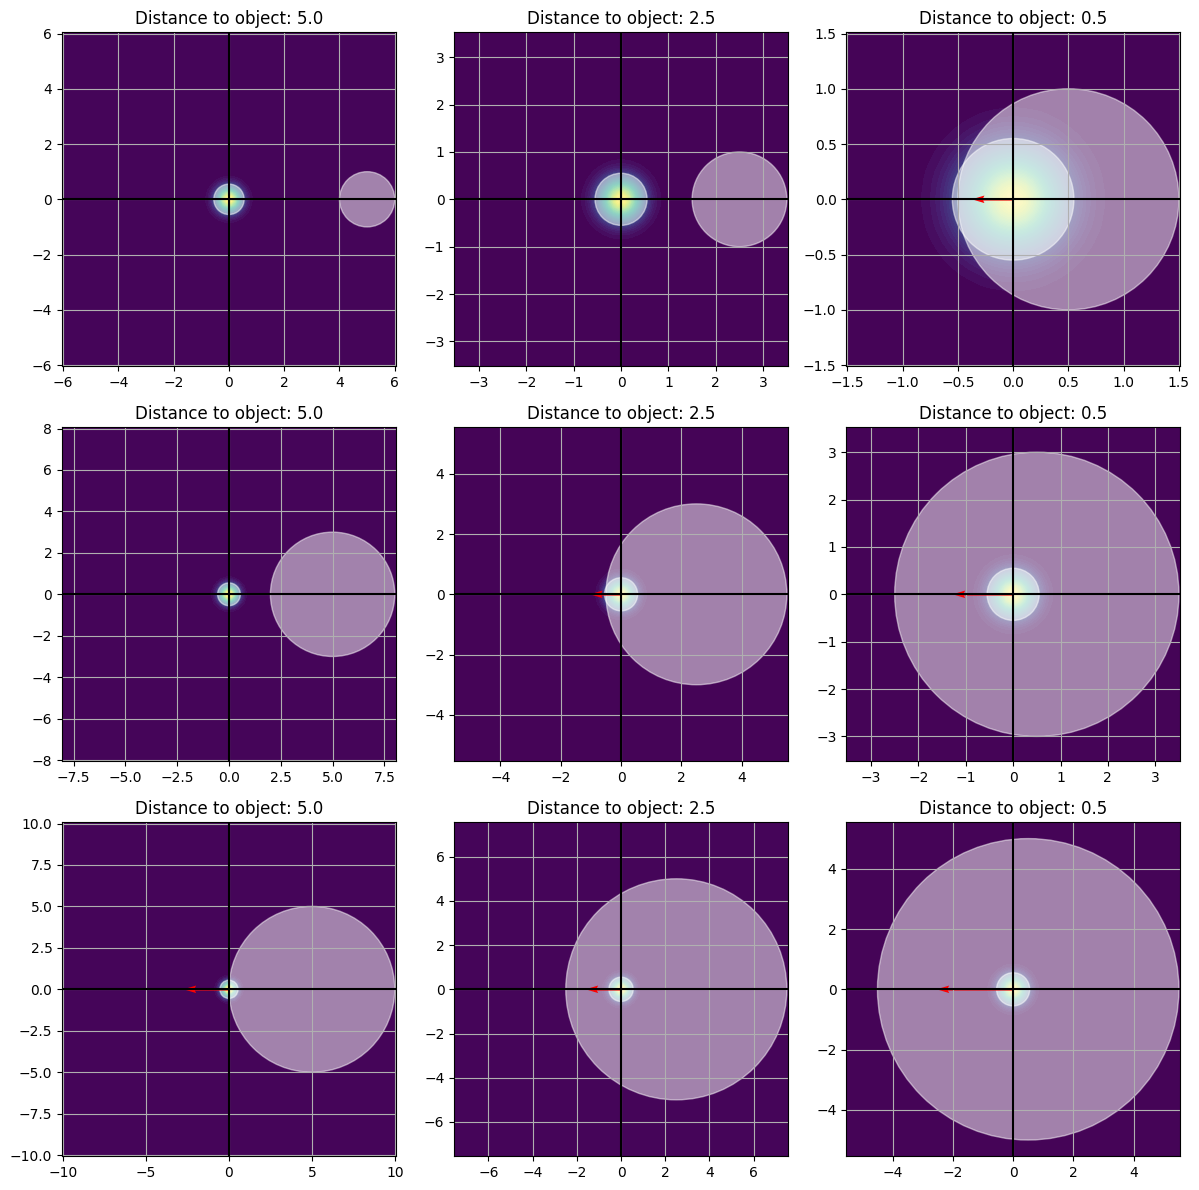

In [125]:
plt.figure(figsize=(12, 12))

i = 1
for obs_rad in [1, 3, 5]:
    for c_x in [5, 2.5, 0.5]:
        plt.subplot(3, 3, i)
        i += 1

        plt.title(f"Distance to object: {c_x:.1f}")

        # if obs_rad != 1 or c_x != 0.5:
        #     continue

        R = obs_rad

        # Color according to Gaussian.
        square_size = c_x + R + 3
        gaussian_xx, gaussian_yy = np.meshgrid(
            np.linspace(-square_size, square_size, 128),
            np.linspace(-square_size, square_size, 128),
        )
        sigma = 0.3
        gaussian_probability = (
            1
            / (2 * np.pi * sigma**2)
            * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma**2)
        )
        plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)

        plt.gca().axvline(x=0, color="k")
        plt.gca().axhline(y=0, color="k")
        plt.grid()
        plt.gca().add_patch(
            patches.Circle((c_x, 0), R, fill=True, color="white", alpha=0.5)
        )
        plt.gca().add_patch(
            patches.Circle((0, 0), 0.55, fill=True, color="white", alpha=0.5)
        )

        t0 = time.time()
        displacement_direction = compute_agent_obstacle_score_vectorized(
            0,
            0,
            c_x,
            0,
            R,
            sigma,
            n_integral=200
        )
        t1 = time.time()
        print(t1 - t0)
        print(c_x, R, displacement_direction)

        plt.quiver(
            0,
            0,
            displacement_direction[0],
            displacement_direction[1],
            color="red",
            scale=5,
        )
        plt.axis("equal")

        plt.xlim(-square_size + 3, square_size - 3)
        plt.ylim(-square_size + 3, square_size - 3)

plt.tight_layout()
plt.show()

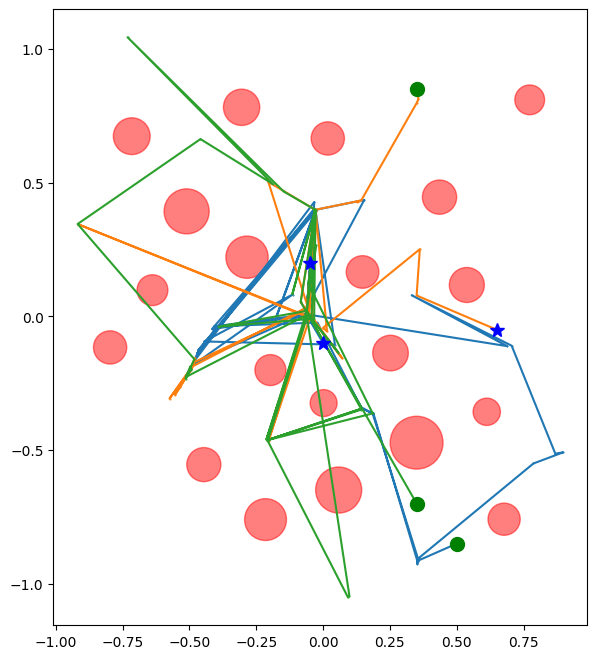

In [ ]:
# Implementing Langevin dynamics!
from dataclasses import dataclass
import json

from matplotlib.axes import Axes
from functools import lru_cache


@dataclass
class Problem:
    num_timesteps: int
    agent_start_positions: np.ndarray
    agent_end_positions: np.ndarray
    agent_reference_trajectory: np.ndarray | None
    agent_radii: np.ndarray
    agent_max_speeds: np.ndarray
    obstacle_positions: np.ndarray
    obstacle_radii: np.ndarray

    @property
    def num_agents(self):
        return self.agent_start_positions.shape[0]

    @property
    def num_obstacles(self):
        return self.obstacle_positions.shape[0]

    def visualize(self, agent_positions: np.ndarray, ax: Axes):
        # Plot the obstacles
        for obs_index in range(self.num_obstacles):
            x, y = self.obstacle_positions[obs_index].tolist()
            ax.add_patch(
                patches.Circle(
                    (x, y), self.obstacle_radii[obs_index].item(), color="r", alpha=0.5
                )
            )

        # Plot the agents' trajectories
        for agent_index in range(self.num_agents):
            if agent_positions.shape[0] == 1:
                x, y = agent_positions[0, agent_index, 0].tolist()
                ax.add_patch(
                    patches.Circle((x, y), self.agent_radii[agent_index].item())
                )
            else:
                ax.plot(
                    agent_positions[:, agent_index, 0],
                    agent_positions[:, agent_index, 1],
                    marker="o",
                    label=f"Agent {agent_index}",
                    # set size to agent radius
                    markersize=self.agent_radii[agent_index].item() * 10,
                )
        # Plot the agents' start and goal positions
        for agent_index in range(self.num_agents):
            (sx, sy) = self.agent_start_positions[agent_index]
            (ex, ey) = self.agent_end_positions[agent_index]
            ax.plot(
                sx,
                sy,
                marker="o",
                color="green",
                markersize=10,
                label=f"Start {agent_index}",
            )
            ax.plot(
                ex,
                ey,
                marker="*",
                color="blue",
                markersize=10,
                label=f"Goal {agent_index}",
            )

        ax.set_aspect("equal")

    @classmethod
    def from_json(cls, entry):
        return cls(
            num_timesteps=entry["num_timesteps"],
            agent_start_positions=np.array(entry["agents"]["start_positions"]),
            agent_end_positions=np.array(entry["agents"]["end_positions"]),
            agent_radii=np.array(entry["agents"]["radii"]),
            agent_max_speeds=np.array(entry["agents"]["max_speeds"]),
            agent_reference_trajectory=None,
            obstacle_positions=np.array(entry["obstacles"]["positions"]),
            obstacle_radii=np.array(entry["obstacles"]["radii"]),
        )


@lru_cache(maxsize=16)
def get_velocity_kernel(N: int, sigma: float):
    velocity_kernel = np.zeros((N - 1, N))
    velocity_kernel[:, 1:] = np.eye(N - 1)
    velocity_kernel -= np.eye(N - 1, N)
    VTV = velocity_kernel.T @ velocity_kernel
    score_kernel = -np.linalg.inv(VTV + np.eye(N) / (sigma**2)) @ VTV
    return score_kernel


def compute_kinetic_energy_score(trajectory: np.ndarray, sigma):
    return np.einsum(
        "it,tad->iad", get_velocity_kernel(trajectory.shape[0], sigma), trajectory
    )


def clip_magnitude(vector, max_magnitude):
    magnitude = np.linalg.norm(vector)
    if magnitude > max_magnitude:
        return vector / magnitude * max_magnitude
    else:
        return vector


def step_langevin(trajectory, sigma, step_size, problem: Problem):
    score = compute_kinetic_energy_score(trajectory, sigma)

    for t in range(trajectory.shape[0]):
        for agent in range(trajectory.shape[1]):
            agent_x = trajectory[t, agent, 0]
            agent_y = trajectory[t, agent, 1]

            for obs_idx in range(obstacle_positions.shape[0]):
                obs_x = obstacle_positions[obs_idx, 0]
                obs_y = obstacle_positions[obs_idx, 1]
                obs_rad = obstacle_radii[obs_idx]

                score[t, agent] += clip_magnitude(
                    compute_agent_obstacle_score(
                        agent_x,
                        agent_y,
                        obs_x,
                        obs_y,
                        obs_rad + problem.agent_radii[agent],
                        sigma,
                    ),
                    1.0,
                )

            for other_agent in range(trajectory.shape[1]):
                if other_agent == agent:
                    continue
                other_agent_x = trajectory[t, other_agent, 0]
                other_agent_y = trajectory[t, other_agent, 1]

                score[t, agent] += clip_magnitude(
                    compute_agent_obstacle_score(
                        agent_x,
                        agent_y,
                        other_agent_x,
                        other_agent_y,
                        problem.agent_radii[agent] + problem.agent_radii[other_agent],
                        np.sqrt(2) * sigma,  # sum the variances
                    ),
                    1.0,
                )

    return (
        trajectory + step_size * score
        # + np.sqrt(2 * step_size) * np.random.randn(*trajectory.shape)
    )


with open("../instances_data/instances_dense.json") as f:
    instances = json.load(f)

instance = instances[0]
start_positions = np.array(instance["agents"]["start_positions"])
end_positions = np.array(instance["agents"]["end_positions"])
obstacle_positions = np.array(instance["obstacles"]["positions"])
obstacle_radii = np.array(instance["obstacles"]["radii"])

problem = Problem.from_json(instance)
trajectory = np.random.randn(64, len(instance["agents"]["start_positions"]), 2)
trajectory[0] = start_positions
trajectory[-1] = end_positions

for sigma in [0.1]:
    for i in range(20):
        trajectory = step_langevin(trajectory, sigma=sigma, step_size=sigma, problem=problem)
        trajectory[0] = start_positions
        trajectory[-1] = end_positions

# Visualize the trajectory.
fig, ax = plt.subplots(figsize=(8, 8))
problem.visualize(trajectory, ax)
plt.show()
